# Clustering de Estratégia Alimentar (Dietary Strategy Clustering)

Este notebook prepara os dados e realiza agrupamento (clustering) das variáveis de alimentação dos rebanhos a partir do conjunto de dados `data/raw/calculate_data.csv` para determinar a variável categórica `Dietary_Strategy_Cluster`.

In [1]:
import os
import sys
import pandas as pd
import numpy as np

# Ajusta o diretório de trabalho se necessário para a raiz do projeto
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

# Configuração para exibir todas as colunas do dataset
pd.set_option('display.max_columns', None)

## 1. Importação dos Dados

Carregamos o dataset original `data/raw/calculate_data.csv`.

In [3]:
df = pd.read_csv('data/raw/calculate_data.csv', sep=';')
print(f"Dimensões do dataset original: {df.shape}")

Dimensões do dataset original: (50, 72)


## 2. Filtragem das Variáveis de Alimentação

Filtramos as 34 variáveis que representam as quantidades de alimentos de diferentes tipos fornecidas aos rebanhos (de `Grass_Fresh` a `Brewers_Grain_Brewery_Residue`).

In [4]:
feed_cols = [
    'Grass_Fresh', 'Grass_Hay_On_Farm', 'Grass_Hay_Off_Farm', 'Grass_Silage_On_Or_Off_Farm',
    'Maize_Silage', 'Lucerne_Alfalfa_Silage', 'Other_Fodder', 'Straw_Peanut_Hull_Others',
    'Crop_Residues', 'Hay_Oat_Clover', 'Sorghum_Silage', 'Wheat', 'Barley', 'Maize_Grain',
    'Oats', 'Rice', 'Rye', 'Sorghum', 'Other_Cereals', 'DDG', 'Soybean_Meal_Hull',
    'Sugarbeet_Molasses', 'Whey_Powder', 'Rapeseed_Cake_Meal', 'Sunflower_Cake_Meal',
    'Cottonseed_Cake_Meal', 'Beans_Peas', 'Cassava_Tapioca', 'Other_Feed', 'Milk_Powder_Dry_Matter',
    'Citrus_Pulp', 'Mineral_Mix', 'Lucerne_Alfalfa_Hay', 'Brewers_Grain_Brewery_Residue'
]

df_feed = df[feed_cols]
print(f"Dimensões do dataset filtrado: {df_feed.shape}")

Dimensões do dataset filtrado: (50, 34)


## 3. Análise Exploratória do Dataset (Variáveis Alimentares)

Dados analisados inicialmente:
- **a) Valores nulos**
- **b) Valores iguais a zero por coluna**
- **c) Valores iguais a zero por linha**
- **d) Dados sumários do dataset (médias, etc. padrão do pandas)**

### a) Valores Nulos

Verificamos se existem valores nulos (NaN) no dataset filtrado.

In [5]:
nulls_per_col = df_feed.isnull().sum()
nulls_per_row = df_feed.isnull().sum(axis=1)
print(f"Total de valores nulos por coluna: {nulls_per_col.sum()}")
print(f"Total de linhas com valores nulos: {(nulls_per_row > 0).sum()}")

Total de valores nulos por coluna: 0
Total de linhas com valores nulos: 0


### b) Valores Iguais a Zero por Coluna

Verificamos a quantidade de valores iguais a zero (0) para cada uma das 34 variáveis de alimentação.

In [6]:
zeros_per_col = (df_feed == 0).sum()
print("Valores iguais a zero por coluna:")
print(zeros_per_col)

Valores iguais a zero por coluna:
Grass_Fresh                       7
Grass_Hay_On_Farm                36
Grass_Hay_Off_Farm               48
Grass_Silage_On_Or_Off_Farm      46
Maize_Silage                     13
Lucerne_Alfalfa_Silage           50
Other_Fodder                     47
Straw_Peanut_Hull_Others         48
Crop_Residues                    50
Hay_Oat_Clover                   41
Sorghum_Silage                   47
Wheat                            50
Barley                           49
Maize_Grain                      38
Oats                             45
Rice                             50
Rye                              50
Sorghum                          50
Other_Cereals                    50
DDG                              50
Soybean_Meal_Hull                 9
Sugarbeet_Molasses               50
Whey_Powder                      50
Rapeseed_Cake_Meal               50
Sunflower_Cake_Meal              50
Cottonseed_Cake_Meal             47
Beans_Peas                    

### c) Valores Iguais a Zero por Linha

Contamos quantos valores iguais a zero (0) existem em cada linha (fazenda) e analisamos a distribuição dessa contagem.

In [7]:
zeros_per_row = (df_feed == 0).sum(axis=1)
print("Distribuição da quantidade de zeros por linha:")
print(zeros_per_row.value_counts().sort_index())

Distribuição da quantidade de zeros por linha:
26     3
27     2
28     5
29     5
30    14
31     9
32    11
33     1
Name: count, dtype: int64


### d) Dados Sumários do Dataset (Pandas describe)

Sumário estatístico padrão contendo médias, desvios padrões, mínimos, quartis e máximos das 34 variáveis alimentares.

In [8]:
df_feed.describe()

,Grass_Fresh,Grass_Hay_On_Farm,Grass_Hay_Off_Farm,Grass_Silage_On_Or_Off_Farm,Maize_Silage,Lucerne_Alfalfa_Silage,Other_Fodder,Straw_Peanut_Hull_Others,Crop_Residues,Hay_Oat_Clover,Sorghum_Silage,Wheat,Barley,Maize_Grain,Oats,Rice,Rye,Sorghum,Other_Cereals,DDG,Soybean_Meal_Hull,Sugarbeet_Molasses,Whey_Powder,Rapeseed_Cake_Meal,Sunflower_Cake_Meal,Cottonseed_Cake_Meal,Beans_Peas,Cassava_Tapioca,Other_Feed,Milk_Powder_Dry_Matter,Citrus_Pulp,Mineral_Mix,Lucerne_Alfalfa_Hay,Brewers_Grain_Brewery_Residue
count,50.000000,50.000000,50.000000,50.000000,5.000000e+01,50.0,50.00000,50.000000,50.0,50.000000,50.000000,50.0,50.000000,50.000000,50.000000,50.0,50.0,50.0,50.0,50.0,50.000000,50.0,50.0,50.0,50.0,50.000000,50.0,50.0,50.000000,50.000000,50.0,50.000000,50.000000,50.0
mean,85398.904000,11095.124000,474.792000,1719.880000,1.370014e+05,0.0,10302.56300,767.449000,0.0,1459.416000,189.654000,0.0,438.000000,13165.477000,3235.652000,0.0,0.0,0.0,0.0,0.0,76849.509000,0.0,0.0,0.0,0.0,2854.154000,0.0,0.0,11100.234000,659.190000,0.0,1106.023000,150.234000,0.0
std,92556.698558,34824.630552,2429.325903,6611.256334,2.362952e+05,0.0,49329.94669,4429.941073,0.0,6153.009874,970.357686,0.0,3097.127702,41880.382348,15185.970167,0.0,0.0,0.0,0.0,0.0,132728.520335,0.0,0.0,0.0,0.0,15440.619243,0.0,0.0,55042.677361,2990.731835,0.0,3510.656982,935.939844,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0,0.00000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
25%,27747.300000,0.000000,0.000000,0.000000,3.193750e+02,0.0,0.00000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,4353.537500,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
50%,68163.750000,0.000000,0.000000,0.000000,4.215750e+04,0.0,0.00000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,33397.500000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
75%,106609.200000,1825.000000,0.000000,0.000000,1.273512e+05,0.0,0.00000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,75012.975000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
max,484917.100000,181916.000000,14924.850000,36500.000000,1.024920e+06,0.0,249550.50000,30473.850000,0.0,41518.750000,6570.000000,0.0,21900.000000,266085.000000,102652.600000,0.0,0.0,0.0,0.0,0.0,659044.000000,0.0,0.0,0.0,0.0,104988.600000,0.0,0.0,321229.200000,15768.000000,0.0,15914.000000,6570.000000,0.0


## 4. Limpeza das variáveis zeradas
Como há colunas de variáveis com valores completamente zerados, iremos remover essas features, buscando redução de dimensionalidade. 

In [9]:
df_feed_clean = df_feed.loc[:, (df_feed != 0).any(axis=0)]

removed_cols = df_feed.shape[1] - df_feed_clean.shape[1]
print(f"Colunas originais: {df_feed.shape[1]}")
print(f"Colunas removidas (todos os valores eram 0): {removed_cols}")
print(f"Dimensões do dataset limpo para clustering: {df_feed_clean.shape}\n")
print(f"Variáveis que ficaram: {df_feed_clean.columns}\n")

Colunas originais: 34
Colunas removidas (todos os valores eram 0): 16
Dimensões do dataset limpo para clustering: (50, 18)

Variáveis que ficaram: Index(['Grass_Fresh', 'Grass_Hay_On_Farm', 'Grass_Hay_Off_Farm',
       'Grass_Silage_On_Or_Off_Farm', 'Maize_Silage', 'Other_Fodder',
       'Straw_Peanut_Hull_Others', 'Hay_Oat_Clover', 'Sorghum_Silage',
       'Barley', 'Maize_Grain', 'Oats', 'Soybean_Meal_Hull',
       'Cottonseed_Cake_Meal', 'Other_Feed', 'Milk_Powder_Dry_Matter',
       'Mineral_Mix', 'Lucerne_Alfalfa_Hay'],
      dtype='str')



## 5. Aplicando clustering

### a) Hierarchical clustering como preparação para Agglomerative clustering

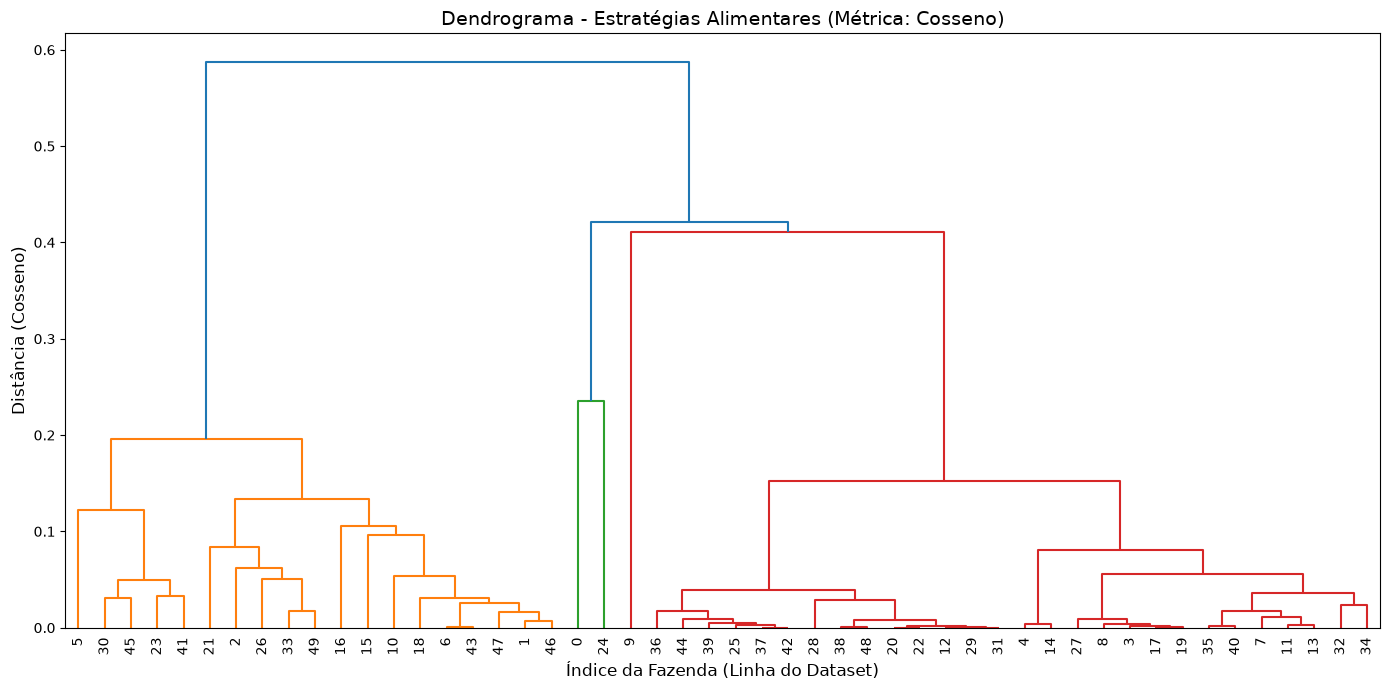

In [10]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(df_feed_clean, method='average', metric='cosine')

plt.figure(figsize=(14, 7))
plt.title('Dendrograma - Estratégias Alimentares (Métrica: Cosseno)', fontsize=14)
plt.xlabel('Índice da Fazenda (Linha do Dataset)', fontsize=12)
plt.ylabel('Distância (Cosseno)', fontsize=12)

# Gera a árvore visual
dendrogram(
    Z,
    leaf_rotation=90.,      # Rotaciona os números das fazendas para facilitar leitura
    leaf_font_size=10.,     # Tamanho da fonte dos rótulos do eixo X
    color_threshold=None    # O scipy tentará colorir os clusters automaticamente
)

plt.tight_layout()
plt.show()

Aplicamos o agrupamento hierárquico (hierarquical clustering), baseando a escolha em nossa [Revisão Sistemática](https://www.scitepress.org/Link.aspx?doi=10.5220/0015044100004018) (era um dos algoritmos de clustering usados nesse domínio), e porque ele é altamente eficaz e interpretável para amostras pequenas, operando de baixo para cima para unir iterativamente as fazendas mais semelhantes de dois em dois clusters (começando por 1 fazenda = 1 cluster) e mapear toda a estrutura dos dados em um dendrograma visual.

A escolha da métrica de Cosseno foi devido à alta esparsidade (excesso de zeros) das variáveis. Ao invés de medir a distância absoluta, o cosseno avalia o ângulo dos vetores, agrupando as dietas pela proporção dos insumos e ignorando a ausência mútua de ingredientes, portanto. Isso se dá pela intuição de que as dietas não são caracterizadas apenas pela diversidade de alimentos (quais alimentos estão na dieta), mas também pela proporção de cada um deles. Duas dietas com os ingredientes (A,B,C) podem ser definitivamente diferentes se uma for intensiva em A e outra em B, por exemplo. 

Por fim, analisando o dendrograma, o número de clusters foi definido como k=4, identificando a maior janela de distância vertical contínua onde não ocorrem novas fusões (entre aproximadamente y=0.4 e y=0.24), o que garante matematicamente a formação de grupos nutricionais mais sólidos, distintos e com alto poder de explicabilidade.

### b) Aplicando agglomerative clustering com k=4 para separar os registros

In [11]:
from sklearn.cluster import AgglomerativeClustering

cluster_model = AgglomerativeClustering(
    n_clusters=4,
    metric='cosine',
    linkage='average'
)

# Treinando o modelo e gerando os rótulos
# O modelo lê a matriz limpa e devolve um array com valores [0, 1, 2, 3]
cluster_labels = cluster_model.fit_predict(df_feed_clean)

# Anexando o resultado ao dataset original
# Criamos a variável categórica Dietary_Strategy_Cluster
df['Dietary_Strategy_Cluster'] = cluster_labels

# Verificando a distribuição (quantas fazendas caíram em cada grupo)
clusters_dist = df['Dietary_Strategy_Cluster'].value_counts().sort_index()

print("Distribuição das fazendas por cluster:")
print(clusters_dist)

Distribuição das fazendas por cluster:
Dietary_Strategy_Cluster
0     2
1    19
2    28
3     1
Name: count, dtype: int64


Com os registros devidamente separados por seus clusters, podemos entender as características deles: quantas fazendas por cluster, quais fazendas são essas e de onde elas são. 

In [12]:
# Iterando por cada cluster único para resumir suas fazendas e distribuição geográfica
for cluster_id in sorted(df['Dietary_Strategy_Cluster'].unique()):
    
    cluster_subset = df[df['Dietary_Strategy_Cluster'] == cluster_id]
    farm_indices = cluster_subset.index.tolist()
    
    # Contando as ocorrências de cada localidade neste cluster
    geographic_distribution = cluster_subset['Location'].value_counts().to_dict()
    
    print(f"=== CLUSTER {cluster_id} ===")
    print(f"Total de Fazendas: {len(farm_indices)}")
    print(f"Índices das Fazendas: {farm_indices}")
    print(f"Localizações:")
    for loc, count in geographic_distribution.items():
        print(f"  -> {loc}: {count} fazenda(s)")
    print("-" * 40 + "\n")

=== CLUSTER 0 ===
Total de Fazendas: 2
Índices das Fazendas: [0, 24]
Localizações:
  -> Santa Catarina: 2 fazenda(s)
----------------------------------------

=== CLUSTER 1 ===
Total de Fazendas: 19
Índices das Fazendas: [1, 2, 5, 6, 10, 15, 16, 18, 21, 23, 26, 30, 33, 41, 43, 45, 46, 47, 49]
Localizações:
  -> Rio Grande do Sul: 15 fazenda(s)
  -> Santa Catarina: 4 fazenda(s)
----------------------------------------

=== CLUSTER 2 ===
Total de Fazendas: 28
Índices das Fazendas: [3, 4, 7, 8, 11, 12, 13, 14, 17, 19, 20, 22, 25, 27, 28, 29, 31, 32, 34, 35, 36, 37, 38, 39, 40, 42, 44, 48]
Localizações:
  -> Rio Grande do Sul: 18 fazenda(s)
  -> Santa Catarina: 5 fazenda(s)
  -> Minas Gerais: 3 fazenda(s)
  -> Pernambuco: 1 fazenda(s)
  -> São Paulo: 1 fazenda(s)
----------------------------------------

=== CLUSTER 3 ===
Total de Fazendas: 1
Índices das Fazendas: [9]
Localizações:
  -> Pernambuco: 1 fazenda(s)
----------------------------------------



Em uma visualização de gráfico de bolhas:

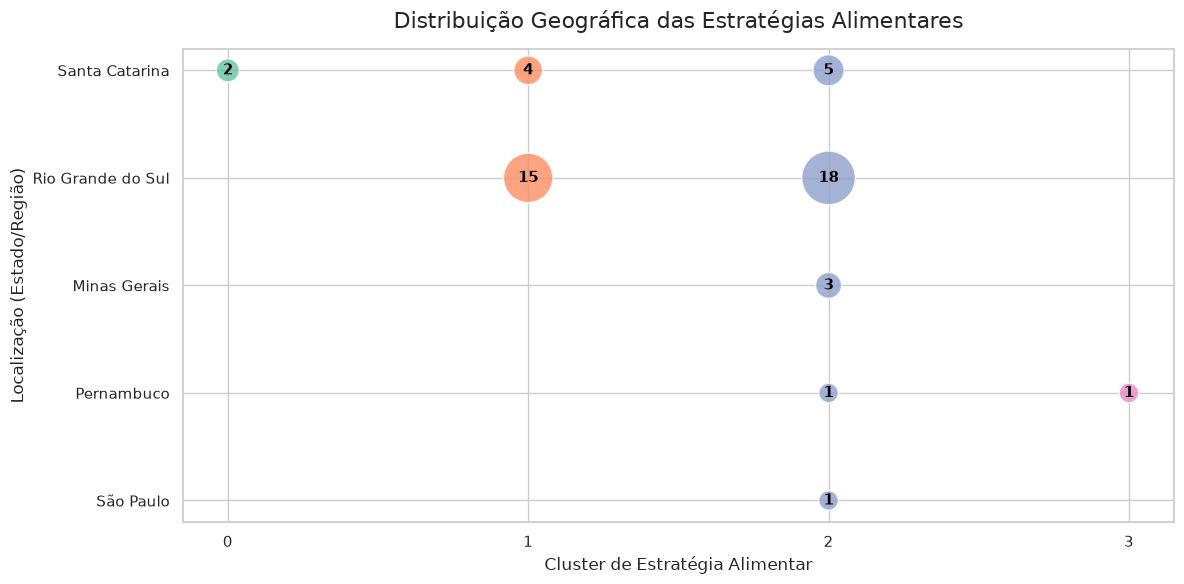

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

bubble_data = df.groupby(['Dietary_Strategy_Cluster', 'Location']).size().reset_index(name='Farm_Count')

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

bubble_plot = sns.scatterplot(
    data=bubble_data,
    x='Dietary_Strategy_Cluster',
    y='Location',
    size='Farm_Count',
    hue='Dietary_Strategy_Cluster', 
    sizes=(200, 1500),             
    palette='Set2',                
    alpha=0.8,                      
    legend=False
)

plt.title('Distribuição Geográfica das Estratégias Alimentares', fontsize=16, pad=15)
plt.xlabel('Cluster de Estratégia Alimentar', fontsize=12)
plt.ylabel('Localização (Estado/Região)', fontsize=12)

plt.xticks(sorted(df['Dietary_Strategy_Cluster'].unique()))

for index, row in bubble_data.iterrows():
    plt.text(
        x=row['Dietary_Strategy_Cluster'], 
        y=row['Location'], 
        s=str(row['Farm_Count']), 
        color='black', 
        ha='center', 
        va='center', 
        fontsize=11, 
        fontweight='bold'
    )
plt.tight_layout()
plt.show()

## 6. Interpretando os clusters formados (em termos de dieta)

In [14]:
df_feed_profile = df_feed_clean.copy()
df_feed_profile['Dietary_Strategy_Cluster'] = df['Dietary_Strategy_Cluster']

# Calculando a média de cada insumo consumido por cluster
cluster_means = df_feed_profile.groupby('Dietary_Strategy_Cluster').mean()
cluster_profile = cluster_means.T

# Aplicando um mapa de calor nativo do Pandas
# O axis=1 garante que a comparação de cores (do mais claro para o mais escuro) seja feita por linha (insumo)
styled_profile = cluster_profile.style.background_gradient(cmap='YlGn', axis=1) \
                                    .format("{:.2f}")
display(styled_profile)

Dietary_Strategy_Cluster,0,1,2,3
Grass_Fresh,28331.30,40549.96,115150.85,218609.45
Grass_Hay_On_Farm,0.00,27403.82,1217.27,0.00
Grass_Hay_Off_Farm,0.00,1249.45,0.00,0.00
Grass_Silage_On_Or_Off_Farm,0.00,3334.95,808.21,0.00
Maize_Silage,0.00,308229.44,35489.60,0.00
Other_Fodder,0.00,13977.77,0.00,249550.50
Straw_Peanut_Hull_Others,0.00,2019.60,0.00,0.00
Hay_Oat_Clover,0.00,1564.70,1544.34,0.00
Sorghum_Silage,0.00,153.30,234.64,0.00
Barley,0.00,1152.63,0.00,0.00


Aqui observamos que:
- A dieta 0 contém apenas Grass_Fresh, Maize_Grain e Soybean_Meal_Hull, com quantidades equilibradas desses elementos.
- A dieta 1 é a mais diversificada e ampla de todas.
- A dieta 2 é intensiva em Grass_Fresh, mas conta com outros elementos relevantes como Mineral_Mix, Hay_Oat_Clover e  Maize_Silage.
- A dieta 3 usa praticamente os mesmos elementos da dieta 0, mas com adição do Other_Fodder, e com escala geral bem maior.

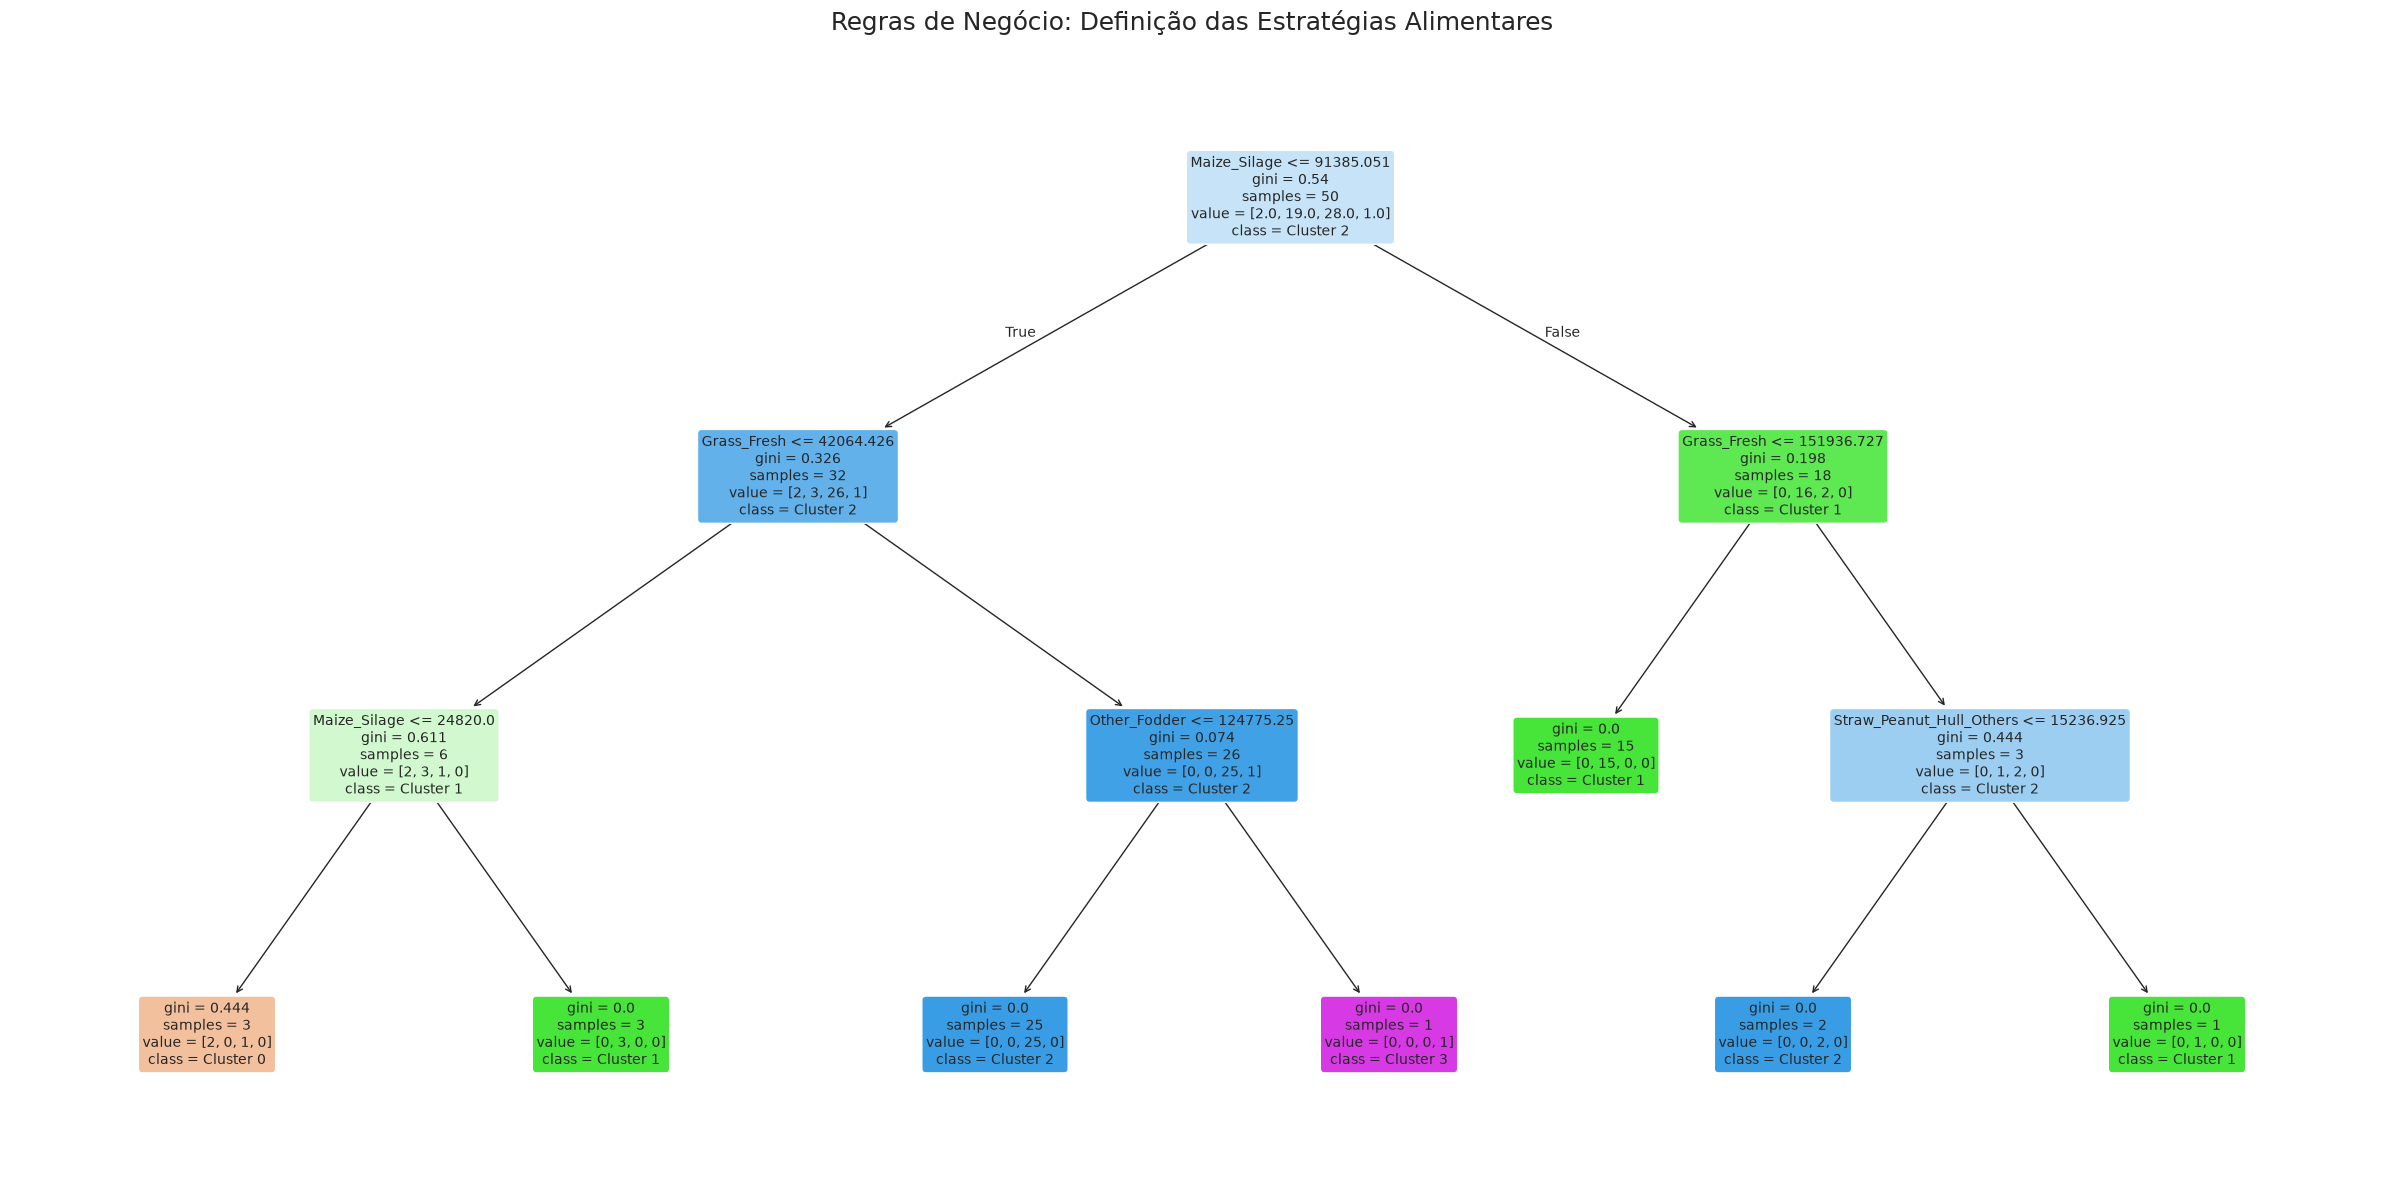

In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Definindo as variáveis preditoras (X) e a variável alvo (y)
X = df_feed_clean
y = df['Dietary_Strategy_Cluster']

# 2. Instanciando o classificador da Árvore de Decisão
# Usamos max_depth=3 para manter a árvore simples, visual e evitar overfitting
# random_state=42 garante que o resultado seja sempre o mesmo a cada execução
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)

# 3. Treinando o modelo
dt_model.fit(X, y)

# 4. Preparando os rótulos das classes para o gráfico (ex: "Cluster 0", "Cluster 1")
class_labels = [f"Cluster {c}" for c in sorted(y.unique())]
feature_cols = X.columns.tolist()

# 5. Plotando a Árvore de Decisão
plt.figure(figsize=(24, 12))
plot_tree(
    dt_model,
    feature_names=feature_cols,
    class_names=class_labels,
    filled=True,          # Colore as caixinhas conforme a classe predominante
    rounded=True,         # Arredonda as bordas
    fontsize=10,          # Tamanho da fonte legível
    proportion=False      # Mostra a contagem absoluta de fazendas nas caixas
)

plt.title("Regras de Negócio: Definição das Estratégias Alimentares", fontsize=18, pad=20)
plt.tight_layout()
plt.show()

Aqui treinamos um modelo de árvore de decisão simples (com baixa profundidade) como estratégia de Modelo Supervisionado para Cluster Profiling (interpretação do modelo não supervisionado). Estamos provendo essa árvore de decisão como forma de análise mais aprofundada das dietas para especialistas de domínio. 

## 7. Exportação do Dataset Processado

Nesta etapa final, exportamos o dataset original (`df`), contendo a nova variável categórica `Dietary_Strategy_Cluster`, mas sem as 34 variáveis de alimentação individual (`df_feed`).

O arquivo final é salvo em formato CSV na pasta `data/processed`.

In [17]:
import os

# Garante que o diretório data/processed exista
os.makedirs('data/processed', exist_ok=True)

# Remove as variáveis de alimentação individual (df_feed) do dataset original (df)
df_processed = df.drop(columns=feed_cols)

# Exporta o dataset para a pasta data/processed em formato CSV
output_path = 'data/processed/farms.csv'
df_processed.to_csv(output_path, sep=';', index=False)

print(f"Dataset processado exportado com sucesso para: {output_path}")
print(f"Dimensões do dataset processado: {df_processed.shape}")

Dataset processado exportado com sucesso para: data/processed/farms.csv
Dimensões do dataset processado: (50, 39)
